# 6. Central Limit Theorem – Histogram Experiments

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## (a) Generate 3 distributions and plot histograms

In [2]:
N = 10000  # population size

# Gaussian
gauss = np.random.normal(loc=0, scale=1, size=N)

# Exponential
exp = np.random.exponential(scale=1.0, size=N)

# Chi-square
chi2 = np.random.chisquare(df=4, size=N)


def plot_hist(data, bins, title):
    plt.figure()
    plt.hist(data, bins=bins)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("Counts")
    plt.show()

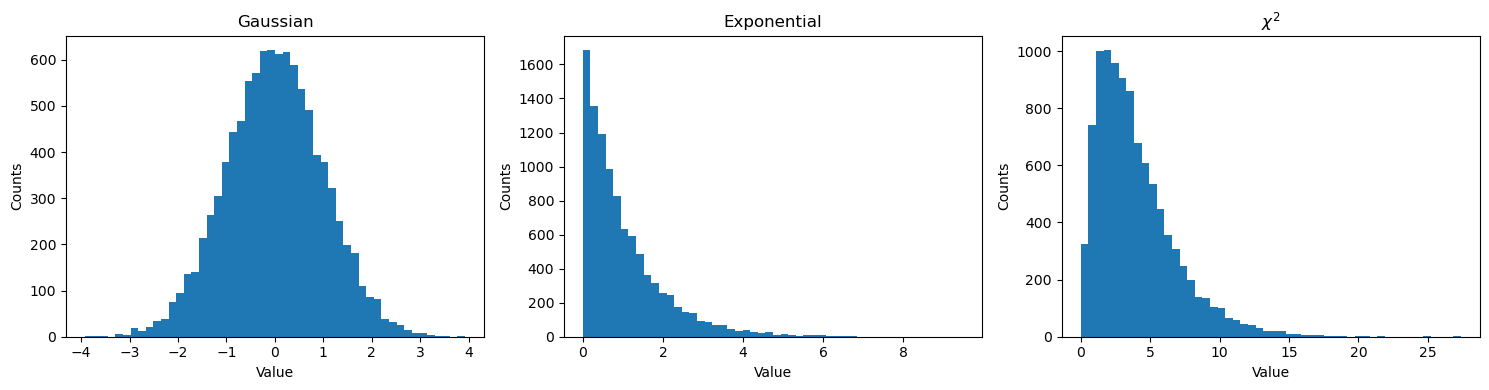

In [3]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(gauss, bins=50)
plt.title("Gaussian")
plt.xlabel('Value')
plt.ylabel('Counts')

plt.subplot(1,3,2)
plt.hist(exp, bins=50)
plt.title("Exponential")
plt.xlabel('Value')
plt.ylabel('Counts')

plt.subplot(1,3,3)
plt.hist(chi2, bins=50)
plt.title(r"$\chi^2$")
plt.xlabel('Value')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

## (b) Combine two distributions

Mean of combined distribution: 0.5122988919707847


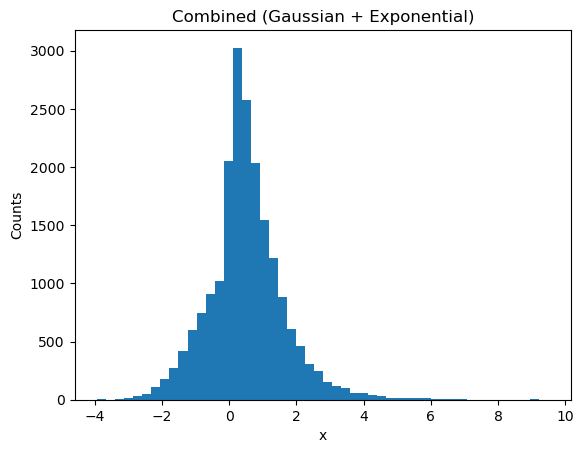

In [4]:
combined = np.concatenate([gauss, exp])

mean_combined = np.mean(combined)
print("Mean of combined distribution:", mean_combined)

plot_hist(combined, bins=50, title="Combined (Gaussian + Exponential)")

Mean (Exp + Chi2): 2.5066415818891046


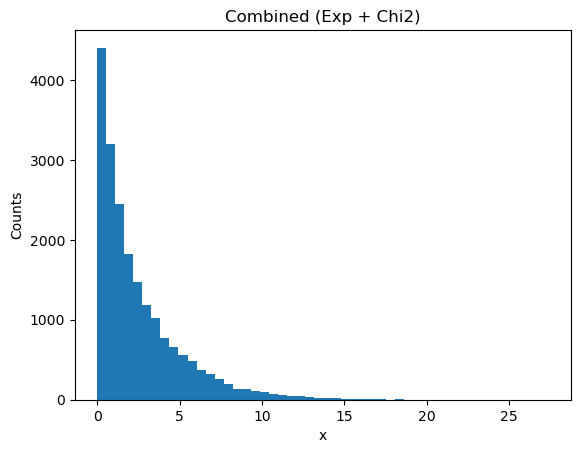

In [5]:
combined2 = np.concatenate([exp, chi2])
print("Mean (Exp + Chi2):", np.mean(combined2))
plot_hist(combined2, bins=50, title="Combined (Exp + Chi2)")

## (c) Sample means (n = 5)

In [6]:
def sample_means(data, n, num_samples):
    means = []
    for _ in range(num_samples):
        sample = np.random.choice(data, size=n)
        means.append(np.mean(sample))
    return np.array(means)

n = 5

means_10 = sample_means(combined, n, 10)
means_100 = sample_means(combined, n, 100)
means_1000 = sample_means(combined, n, 1000)
means_10000 = sample_means(combined, n, 10000)

In [7]:
print("Mean of means (10 samples):", np.mean(means_10))
print("Mean of means (100 samples):", np.mean(means_100))
print("Mean of means (1000 samples):", np.mean(means_1000))
print("Mean of means (10000 samples):", np.mean(means_10000))

Mean of means (10 samples): 0.38918565078176587
Mean of means (100 samples): 0.540903996186319
Mean of means (1000 samples): 0.5113071225816669
Mean of means (10000 samples): 0.5071122707929031


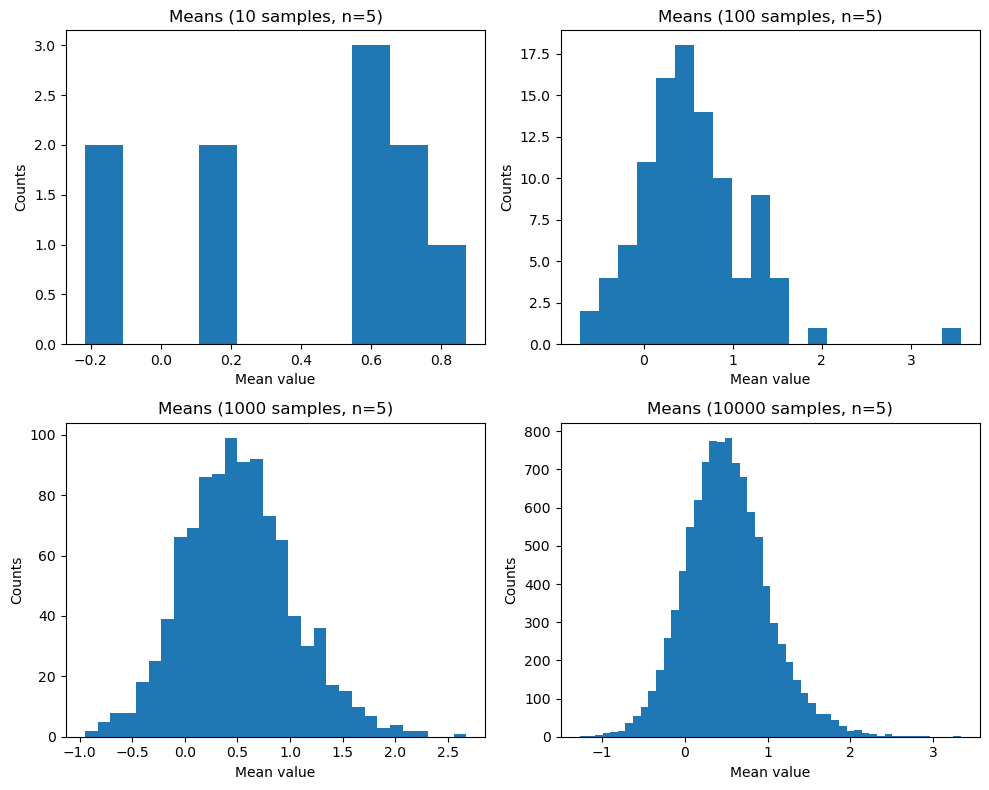

In [8]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.hist(means_10, bins=10)
plt.title("Means (10 samples, n=5)")
plt.xlabel('Mean value')
plt.ylabel('Counts')

plt.subplot(2,2,2)
plt.hist(means_100, bins=20)
plt.title("Means (100 samples, n=5)")
plt.xlabel('Mean value')
plt.ylabel('Counts')

plt.subplot(2,2,3)
plt.hist(means_1000, bins=30)
plt.title("Means (1000 samples, n=5)")
plt.xlabel('Mean value')
plt.ylabel('Counts')

plt.subplot(2,2,4)
plt.hist(means_10000, bins=50)
plt.title("Means (10000 samples, n=5)")
plt.xlabel('Mean value')
plt.ylabel('Counts')

plt.tight_layout()
plt.show()

## (d) Increase sample size n

n = 10, mean of means = 0.5100730454018947
Difference from original mean = -0.002225846568890022
n = 20, mean of means = 0.5129778411782152
Difference from original mean = 0.0006789492074305015
n = 50, mean of means = 0.5119467367698295
Difference from original mean = -0.0003521552009552176


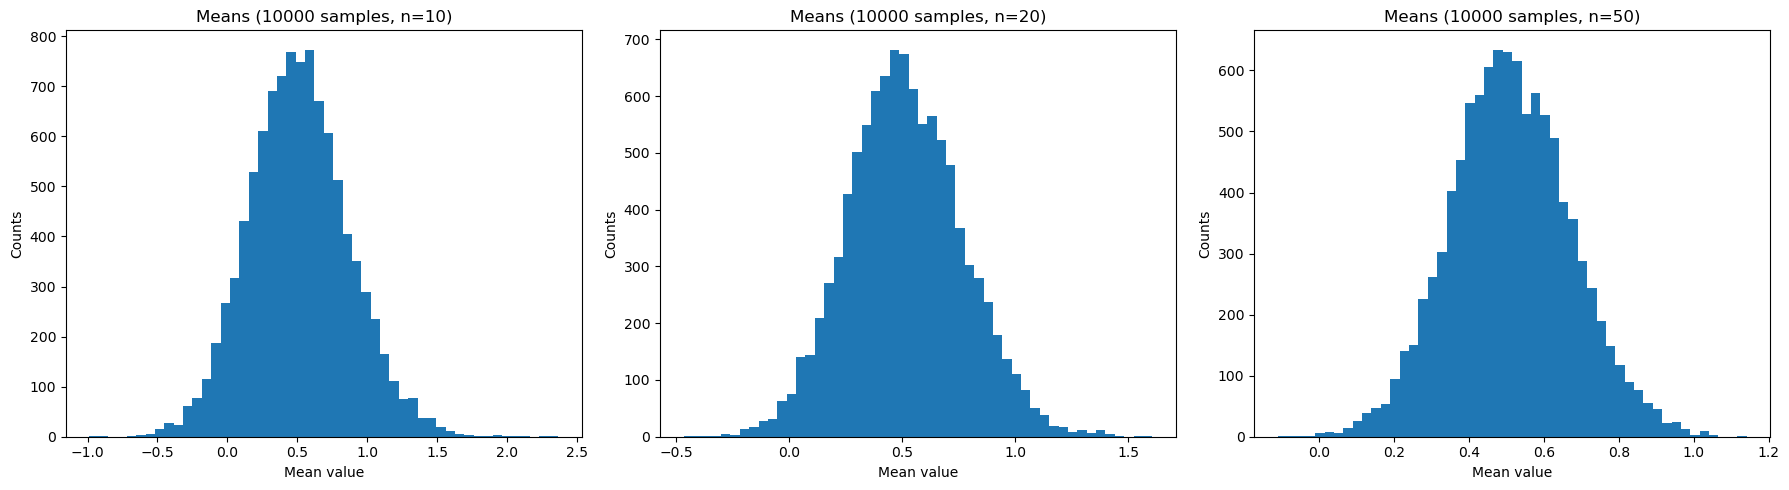

In [9]:
ns = [10, 20, 50]
plt.figure(figsize=(18,5))

for idx, n in enumerate(ns, 1):
    means = sample_means(combined, n, 10000)
    print(f"n = {n}, mean of means =", np.mean(means))
    print(f"Difference from original mean = {np.mean(means) - mean_combined}")
    
    plt.subplot(1,3,idx)
    plt.hist(means, bins=50)
    plt.title(f"Means (10000 samples, n={n})")
    plt.xlabel('Mean value')
    plt.ylabel('Counts')

plt.tight_layout()
plt.show()

## QQ-plot Explanation

The `stats.probplot(means, dist="norm", plot=plt)` does the following:

1. Sorts the data (`means`) in ascending order:  
   $x_{(1)}, x_{(2)}, ..., x_{(N)}$
2. Computes the "theoretical" quantiles of a normal distribution with the same number of points:  
   $ q_i = \Phi^{-1}\left(\frac{i-0.5}{N}\right) $, where $ \Phi^{-1} $ is the inverse CDF of the normal distribution.
3. Plots the actual data (y-axis) against the theoretical normal quantiles (x-axis).
4. Fits a straight line to the points to compare with the ideal normal distribution.

**Interpretation:**
- If the data are normal, the points fall on the straight line.
- If not normal, the points deviate (S-shape, skewness, heavy tails).

**Connection to CLT:**
- For small n, the distribution of sample means deviates from the line.
- For large n, the points approach a straight line, showing that the distribution of sample means approaches Gaussian.



The QQ-plot shows that as the sample size increases, the distribution of sample means approaches a straight line, indicating convergence to a normal distribution, in agreement with the Central Limit Theorem.

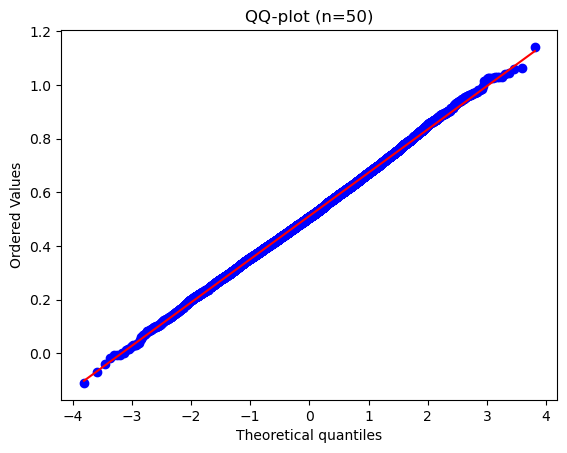

In [10]:
import scipy.stats as stats

stats.probplot(means, dist="norm", plot=plt)
plt.title(f"QQ-plot (n={n})")
plt.show()

# 7.  Random Walk Simulation and CLT Verification

## (a) Simulate 5 independent random walks, n=1000 steps each

In [11]:
n_steps = 1000
num_walks = 5

walks = []
for _ in range(num_walks):
    steps = np.random.uniform(-1, 1, size=n_steps)
    walk = np.cumsum(steps)
    walks.append(walk)

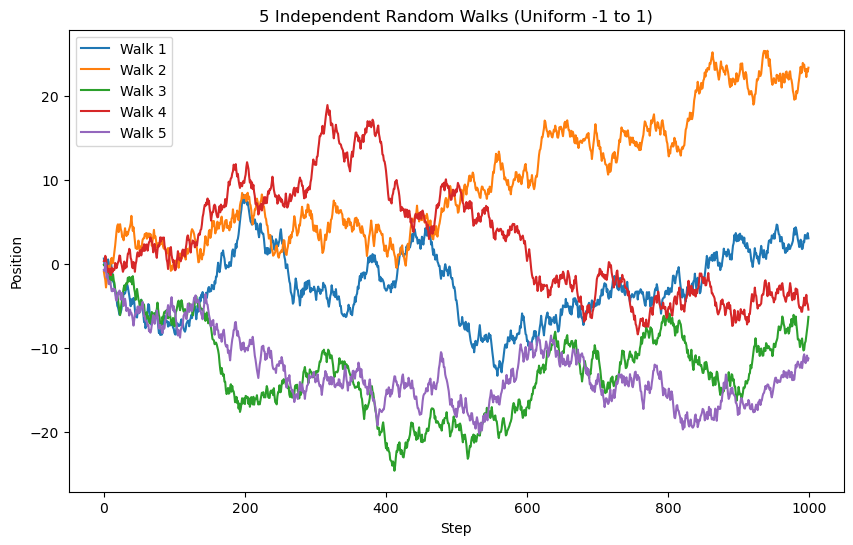

In [12]:
plt.figure(figsize=(10,6))
for i, walk in enumerate(walks, 1):
    plt.plot(walk, label=f'Walk {i}')
plt.xlabel('Step')
plt.ylabel('Position')
plt.title('5 Independent Random Walks (Uniform -1 to 1)')
plt.legend()
plt.show()

## (b) Statistical Study of Final Positions

In [13]:
M = 10000
n_steps_stat = 500
final_positions = np.zeros(M)

for i in range(M):
    steps = np.random.uniform(-1, 1, size=n_steps_stat)
    final_positions[i] = np.sum(steps)

## (c) CLT Verification

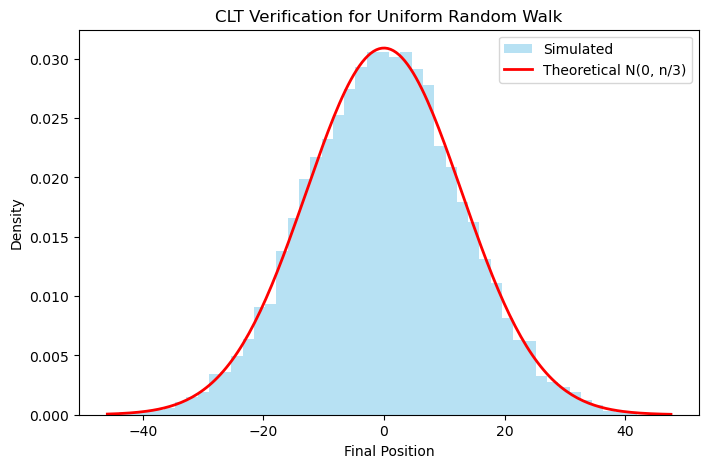

In [14]:
mean_theoretical = 0
std_theoretical = np.sqrt(n_steps_stat / 3)  # Var(U(-1,1)) = 1/3

plt.figure(figsize=(8,5))
count, bins, _ = plt.hist(final_positions, bins=50, density=True, alpha=0.6, color='skyblue', label='Simulated')

x = np.linspace(min(final_positions), max(final_positions), 200)
pdf = (1/(std_theoretical * np.sqrt(2*np.pi))) * np.exp(-(x-mean_theoretical)**2 / (2*std_theoretical**2))
plt.plot(x, pdf, color='red', lw=2, label='Theoretical N(0, n/3)')

plt.xlabel('Final Position')
plt.ylabel('Density')
plt.title('CLT Verification for Uniform Random Walk')
plt.legend()
plt.show()

## (d) Repeat for n = 100, 400, 900 and compute experimental std

n=100, experimental std of final positions: 5.7480, theoretical std: 5.7735
n=400, experimental std of final positions: 11.5034, theoretical std: 11.5470
n=900, experimental std of final positions: 17.3265, theoretical std: 17.3205


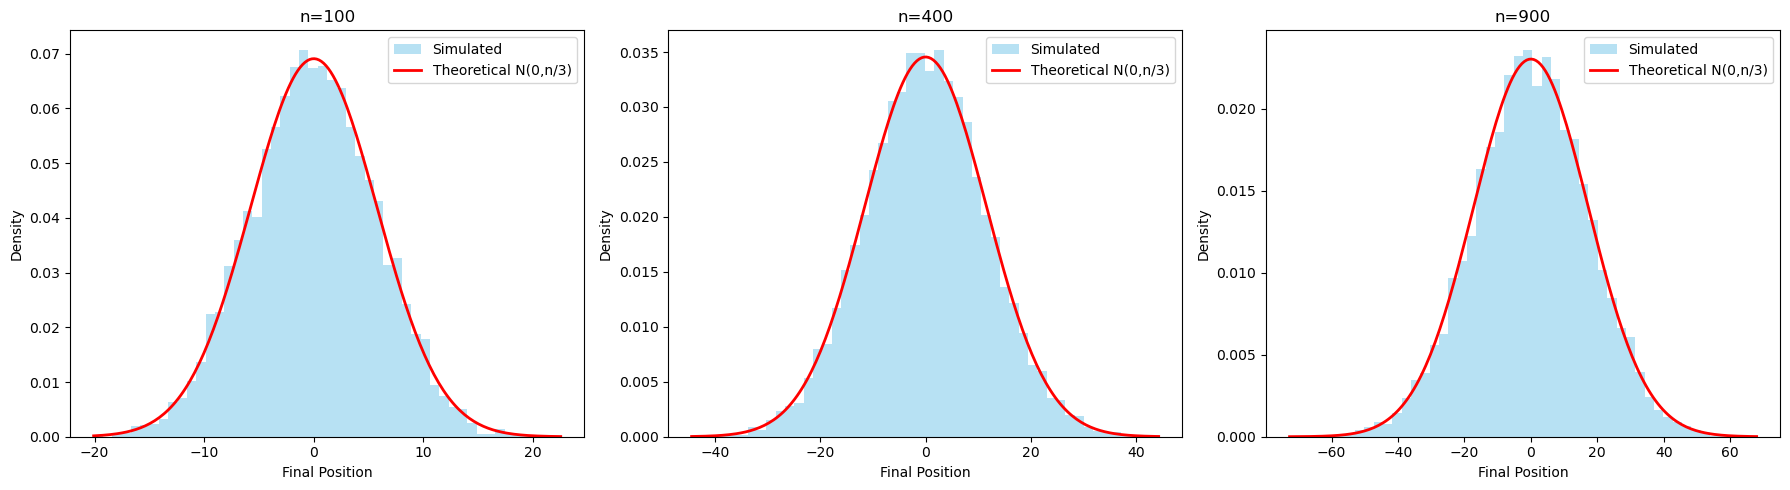

In [15]:
ns = [100, 400, 900]
plt.figure(figsize=(18,5))

for idx, n in enumerate(ns, 1):
    final_positions_n = np.zeros(M)
    for i in range(M):
        steps = np.random.uniform(-1,1,size=n)
        final_positions_n[i] = np.sum(steps)
    exp_std = np.std(final_positions_n)
    print(f'n={n}, experimental std of final positions: {exp_std:.4f}, theoretical std: {np.sqrt(n/3):.4f}')
    
    plt.subplot(1,3,idx)
    count, bins, _ = plt.hist(final_positions_n, bins=50, density=True, alpha=0.6, color='skyblue', label='Simulated')
    x = np.linspace(min(final_positions_n), max(final_positions_n), 200)
    pdf = (1/(np.sqrt(n/3) * np.sqrt(2*np.pi))) * np.exp(-(x-0)**2 / (2*(n/3)))
    plt.plot(x, pdf, color='red', lw=2, label='Theoretical N(0,n/3)')
    plt.title(f'n={n}')
    plt.xlabel('Final Position')
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()